In [3]:
# Generelle moduler og funksjonsbeskrivelser brukt i forelesningen
from numpy import sin, cos, pi, exp, angle, abs, unwrap, log10
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from IPython.display import Audio

plt.rcParams["figure.figsize"] = [8.00, 4.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.xmargin"] = 0.0

%matplotlib inline

# Enable importing from modules in top-level directory
from sys import path
if path[0] != '..': path.insert(0, '..')

<img src="figurer/NTNU_logo_vertical.svg" align="left" width="30%">
<br clear="all" />
<br></br>

# Aliasing og Nyquist Samplingsteorem

* **Emne: AIS2102 - Dynamiske system**
* ***dato***: 14. januar 2026
* **Foreleser: Kai Erik Hoff**

# Tema:

* <font color="d62728">Oppsummering viktige prinsipp</font>
* Aliasing og Nyquist Samplingsteorem
* Valg av sampletid $T_s$

# Oppsummering diskrete system





1. Kontinuerlig input til systemet *diskretiseres* $u[k] = u(k\cdot T_s)$
    - $T_s$ er systemets sampletid.
    - $f_s = \frac{1}{T_s}$ er systemets *samplingsfrekvens*.

3. Digital enhet *rekonstruerer* et tidskontinuerlig signal $\bar{y}(t)$ med f.eks. ZOH.
    - $\bar{y}(t)$ har trappetrinnsform
    - Forenklet modellering som tidsforsinkelse lik $\frac{T_s}{2}$
$$ \bar{y}(t) \approx y\left( t - \frac{T_s}{2} \right) $$

3. Digital regulator bruker tid på å beregne ny utgangsverdi
    - Prosesseringstiden ***må ikke overskride*** sampletiden $T_s$
    - Medregnet prosesseringstid vil total forsinkelse introdusert av digital regulator være $d \in \left(\frac{T_s}{2}, \frac{3\cdot T_s}{2}\right)$

# Tema:

* Oppsummering viktige prinsipp
* <font color="d62728">Aliasing og Nyquist Samplingsteorem</font>
* Valg av sampletid $T_s$

# [Youtube-Video](https://youtu.be/yr3ngmRuGUc)

* Videoen illusrerer en annen utfordring med digitalisering av analoge signal: Aliasing!
* For å få en bedre idé av hva som skjer her, er det nyttig å se på hva som skjer når vi sampler en enkel type signal: en sinusbølge.

## Interaktivt plot: sampling av sinussignal

Output()

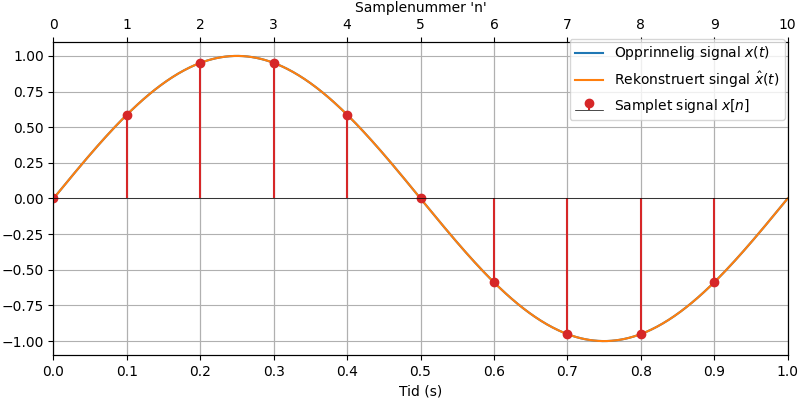

In [5]:
from demos import AliasingDemo
%matplotlib ipympl
AliasingDemo(fig_num=1);

# Nyquist Samplingsteorem

* Et analogt signal $u(t)$ som ikke inneholder frekvenskomponenter høyere enn $f_{max}$ kan rekonstrueres uten feil fra det samplede signalet $u[k] = u(k\cdot T_s)$ *kun* hvis samplingsfrekvensen $f_s =\frac{1}{T_s}$ er større enn $2\cdot f_{max}$.

$$\Large f_s > 2\cdot f_{max} = \text{Nyquist rate}$$

* Maksfrekvensen $\frac{f_s}{2}$ er kjent som *Nyquistfrekvensen*

## Eksempel 1:

* Lydopptak er ofte diskretisert med en samplingsfrekvens $f_s = 44\ 100\ \text{Hz}$.
    - Hva er Nyquistfrekvensen for et slikt lydopptak?
    - Hva kan være årsaken til man har valgt denne samplingsfrekvensen?

# Frekvensfolding

* Frekvensinnhold "speiles" om Nyquistfrekvensen $\frac{f_s}{2}$.
<br>
<img src="figurer/freq_folding_1.png" style="width: 60%; margin-left: 15%" /><br>

## Frekvensfolding illustrert med chirp-signal

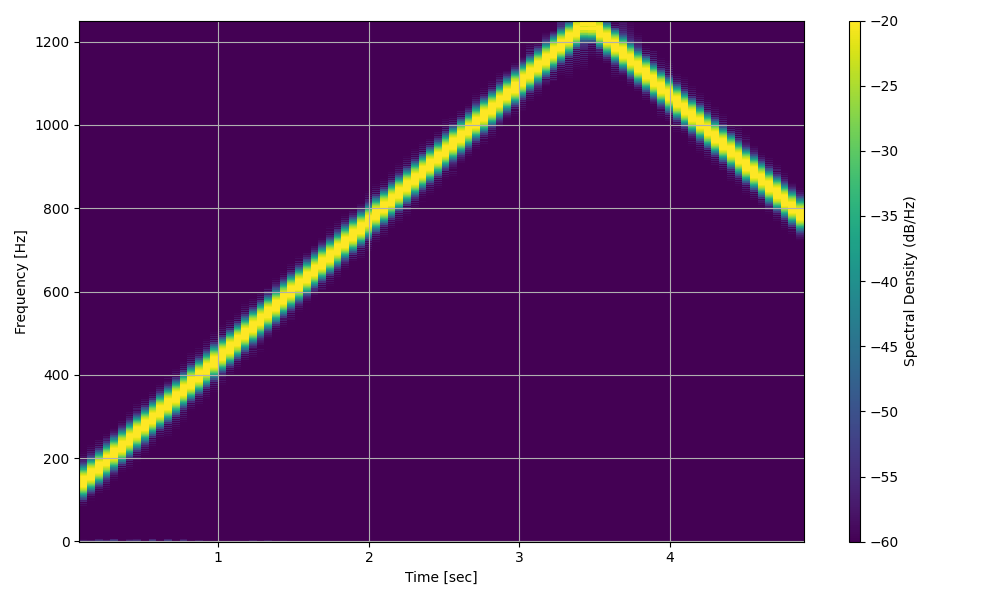

In [6]:
fs = 2500 # Samplet per second
T = 5 # Signalvarighet i seconds
t = np.linspace(0, T, int(T*fs), endpoint=False) # array of sample time values
x_t = sig.chirp(t, f0 = 110, t1=T, f1 = 1760)    # Lag en tone som gradvis øker i frekvens

# Her genereres og vises et spektrogram basert på det genererte chirp-signalet.
# Vi skal snakke om alle du forskjellige parametrene om et par uker, så ikke
# bli forskrekket om det ser helt gresk ut.
plt.close(4); plt.figure(4, figsize=(10,6))

f_axis, t_axis, Sxx = sig.spectrogram(x_t, fs,'hamming', 512, 384, 2048)
plt.pcolormesh(t_axis, f_axis, 10*np.log10(Sxx), vmax =-20, vmin = -60, shading='auto')
plt.colorbar(aspect=50, label=r'Spectral Density (dB/Hz)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.tight_layout();plt.show()

Audio(x_t/max(abs(x_t))/16, rate=fs, normalize=False) # Spill av "x_t" til en Audio widget

# Alternativ illustrasjon av frekvensfolding

<img src="figurer/Fig15_FreqFolding2.png" style="width: 80%">

Output()

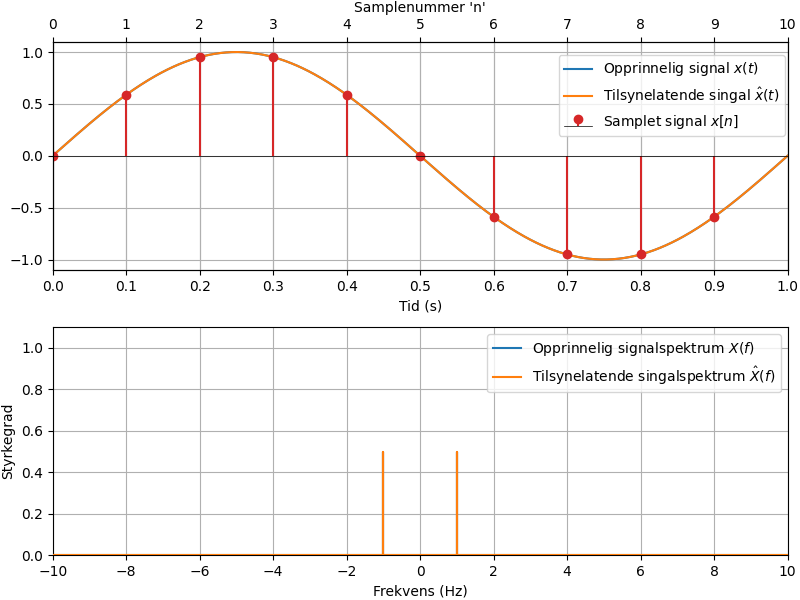

In [8]:
from demos import AliasingDemo2
%matplotlib ipympl
AliasingDemo2(fig_num=1);

## Regneeksempel:

1. Signalet $u(t) = \cos(12\pi \cdot t)$ samples med samplingsfrekvens $f_s = 10$ sampler per sekund. Hva er den tilsynelatende frekvensen til $u(t)$ basert på det samplede signalet $u[k]$.

# Tema:

* Oppsummering viktige prinsipp
* Aliasing og Nyquist Samplingsteorem
* <font color="d62728">Valg av sampletid $T_s$</font>

# Retningslinjer for sampletid $T_s$



* **Absolutt minimumskrav:**
    - Nyquist Samplingsteorem må overholdes

* **Tommelfingerregel for digitale regulatorer:**
    $$T_s \leq \frac{T_r}{5}$$
    - Her er $T_r$ er reguleringssløyfens responstid.
    - Tilnærmet verdi for repsonstid $T_r$ kan utregnes basert på båndbredde $T_r \approx \frac{1}{\omega_b}$ 